# OCR ve Doküman Zekâsı Motor Karşılaştırması — Gerçek Derlem & StudyApp Modelleri

Bu notebook; **StudyApp** projesinde kıyaslanan ve **KACHOW** üretim hattında yer alan doküman işleme motorlarını (`OpenDataLoader-PDF`, `Tesseract (300 DPI + Layout)`, `PaddlePaddle/PaddleOCR`, `ATH-MaaS/OvisOCR2`, `zai-org/GLM-OCR`, `baidu/Unlimited-OCR`, `deepseek-ocr:latest`), **23 gerçek taranmış resmî yazışma belgesi (52 sayfa)** üzerinde kıyaslar.

### İki Boyutlu Kapsamlı Değerlendirme:
1. **StudyApp Ticari Değiş-Tokuş Matrisi (Latency vs. Accuracy vs. Memory Footprint):** Sayfa başına çıkarım süresi (gecikme), tepe bellek kullanımı (RAM/VRAM) ve ağırlıklı başarı skoru üzerinden baloncuk dağılım grafiği (**Scatter Bubble Plot**).
2. **KACHOW Alan Düzeyinde Ayrışma (Header vs. Signature Recovery):** Başlık bölgesi (Sayı/Tarih/Konu/Muhatap/Gönderen) ve ıslak imzanın basılı ismi yok ettiği imza bölgesi (İmza sahibi/unvanı) için çift çubuk grafik (**Dual Bar Chart**).

Skorlama mantığı `scripts/evaluate_ocr_real.py`'de yaşar ve üretim kodunu doğrudan import eder.

**Çalıştırmadan önce**: Colab menüsünden *Çalışma zamanı → Çalışma zamanı türünü değiştir → A100 GPU* seçili olmalı. Ayrıca sol paneldeki 🔑 (Secrets) sekmesine `GITHUB_TOKEN` adıyla bir token eklenmelidir.

## 1. GPU Doğrulama

In [1]:
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv
print()
print("Yukarıda 'A100' görmüyorsanız: Çalışma zamanı > Çalışma zamanı türünü değiştir > A100 GPU, sonra bu hücreyi tekrar çalıştırın.")

name, memory.total [MiB], driver_version
NVIDIA A100-SXM4-40GB, 40960 MiB, 580.82.07

Yukarıda 'A100' görmüyorsanız: Çalışma zamanı > Çalışma zamanı türünü değiştir > A100 GPU, sonra bu hücreyi tekrar çalıştırın.


## 2. Repo Klonu

`GITHUB_TOKEN` Colab Secrets'tan okunur, hiçbir hücreye açık yazılmaz. İmza alanı skorlaması ve StudyApp modelleri `fix/ocr-benchmark-signature-scoring` dalında bulunmaktadır.

In [2]:
from google.colab import userdata
import os

GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")
REPO = "chyp3r/KACHOW-Teknofest-2026"
BRANCH = "fix/ocr-benchmark-signature-scoring"  # main'e merge edildiyse 'main' yapabilirsiniz

clone_url = f"https://{GITHUB_TOKEN}@github.com/{REPO}.git"
!git clone --branch {BRANCH} --depth 1 {clone_url} repo 2>&1 | sed "s/{GITHUB_TOKEN}/***/g"
%cd repo
!git log -1 --oneline -- scripts/evaluate_ocr_real.py

Cloning into 'repo'...
/content/repo
7d19817 (grafted, HEAD -> fix/ocr-benchmark-signature-scoring, origin/fix/ocr-benchmark-signature-scoring) fix(scripts): separate raw/chain timing, honestly label memory estimates


## 3. Sistem Paketleri

Backend Docker ortamıyla birebir aynı: Java (OpenDataLoader PDF için), Tesseract OCR ve Türkçe dil paketi.

In [3]:
!apt-get -qq update
!apt-get -qq install -y default-jre-headless tesseract-ocr tesseract-ocr-tur
!java -version
!tesseract --version | head -1
!tesseract --list-langs | grep -q tur && echo 'tur dil paketi OK' || echo 'HATA: tur dil paketi eksik'

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.31+11-1ubuntu1~22.04.2_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.31+11-1ubuntu1~22.04.2) ...
Selecting previously unselected package default-jre-headless.
Preparing to unpack .../default-jre-headless_2%3a1.11-72build2_amd64.deb ...
Unpacking default-jre-headless (2:1.11-72build2) ...
Selecting previously unselected package tesseract-ocr-tur.
Preparing to unpack .../tesseract-ocr-tur_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-tur (1:4.00~git30-7274cfa-1.1) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.31+11-1ubuntu1~22.04.2) ...
update-alternatives: using /usr/lib/j

## 4. Python Bağımlılıkları

Backend gereksinimleri, event loop uyumluluğu için `nest_asyncio` ve StudyApp modelleri için `paddlepaddle`, `paddleocr` kurulur.

In [4]:
!pip install -q -r backend/requirements.txt nest_asyncio paddlepaddle paddleocr matplotlib
import sys
sys.path.insert(0, "backend")

import nest_asyncio
nest_asyncio.apply()

from app.infrastructure.extractors import FallbackDocumentExtractor  # noqa: F401
print("Backend paketleri ve bağımlılıklar OK")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.8/247.8 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.

## 5. Ollama & Model Hazırlığı

Ollama arka planda başlatılır ve VLM modelleri (`glm-ocr`, `deepseek-ocr`, `unlimited-ocr`) çekilir.

In [7]:
!sudo apt-get update && sudo apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh
!sudo dnf install -y pciutils lshw
import subprocess, time, urllib.request, urllib.error

subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

for attempt in range(30):
    try:
        urllib.request.urlopen("http://localhost:11434/api/tags", timeout=1)
        print(f"Ollama hazır ({attempt + 1}. denemede).")
        break
    except (urllib.error.URLError, ConnectionError):
        time.sleep(1)
else:
    raise RuntimeError("Ollama 30 saniyede ayağa kalkmadı -- `!ollama serve` çıktısını kontrol edin.")

!ollama --version

Get:1 https://cli.github.com/packages stable InRelease [4,685 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 4,685 B in 1s (4,650 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (

In [8]:
import subprocess
for model in ["glm-ocr:latest", "deepseek-ocr:latest", "frob/unlimited-ocr:q8_0"]:
    print(f"--- çekiliyor: {model} ---")
    subprocess.run(["ollama", "pull", model], check=True)
!ollama list

--- çekiliyor: glm-ocr:latest ---
--- çekiliyor: deepseek-ocr:latest ---
--- çekiliyor: frob/unlimited-ocr:q8_0 ---
NAME                       ID              SIZE      MODIFIED               
frob/unlimited-ocr:q8_0    5e0b8e784f09    4.0 GB    Less than a second ago    
deepseek-ocr:latest        0e7b018b8a22    6.7 GB    24 seconds ago            
glm-ocr:latest             6effedd0dc8a    2.2 GB    About a minute ago        


## 6. Duman Testi (Kalite Kapısı)

Tek zorlu belge (`CY-050` — imza basılı ismi bozan belge) ve `glm-ocr` ile duman testi koşulur.

In [9]:
import asyncio, importlib.util, logging
logging.basicConfig(level=logging.INFO)

spec = importlib.util.spec_from_file_location("ev", "scripts/evaluate_ocr_real.py")
ev = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ev)

gt = ev._load_ground_truth()
docs = ev._load_documents(gt)
doc = [d for d in docs if d[0].startswith("CY-050")][0]
print("beklenen alanlar:", sorted(doc[2].keys()), f"-- {len(doc[2])} alan (imza dahil)")
assert len(doc[2]) >= 5 and any(k.startswith("imza") for k in doc[2]), "İmza alanları skorlamada yok -- repo dalının fix/ocr-benchmark-signature-scoring olduğunu doğrulayın!"

name, engine = ev._parse_engine_spec("ollama:glm-ocr:latest")
smoke = asyncio.run(ev._run_engine(name, engine, [doc]))
sig = smoke["totals"]["chain"]["signature"]
print(f"\nzincir imza sonucu: {sig['found']}/{sig['expected']} bulundu")
print("Log'da 'full-page vision transcription' görüldüyse kapı geçti -- 7. hücreye geçebilirsiniz.")

beklenen alanlar: ['imza_sahibi', 'imza_unvani', 'konu', 'sayi', 'tarih'] -- 5 alan (imza dahil)
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
  CY-050_7-41661-isitme-engelli-bireylerin   ham bşl 2/3(t2) imz 2/2(t1) 93.2s  |  zincir bşl 2/3(t2) imz 2/2(t1) 2.6s

zincir imza sonucu: 2/2 bulundu
Log'da 'full-page vision transcription' görüldüyse kapı geçti -- 7. hücreye geçebilirsiniz.


## 7. Tam Koşum (StudyApp Modelleri Dahil)

Aşağıdaki modeller sırayla değerlendirilir ve sonuçlar `ocr_real_results.json`'a birikimli yazılır:
- `opendataloader`: Java tabanlı OpenDataLoader-PDF (~1-2 dk)
- `tesseract`: Tesseract (300 DPI + Layout) (~2-3 dk)
- `paddleocr`: PaddlePaddle/PaddleOCR (~1-2 dk)
- `ollama:glm-ocr:latest`: zai-org/GLM-OCR (~30-40 dk)
- `ollama:frob/unlimited-ocr:q8_0`: Baidu Unlimited-OCR (~30-40 dk)
- `ollama:deepseek-ocr:latest`: DeepSeek-OCR (~35-45 dk)
- *(Opsiyonel)* `sidecar:ovisocr2`: ATH-MaaS/OvisOCR2

> **NOT:** Tüm modellerin tamamlanması toplam ~2-2.5 saat sürer. Her motor tamamlandıkça sonuç diske kaydedilir.

In [10]:
import sys
sys.argv = [
    "evaluate_ocr_real.py",
    "--engine", "opendataloader",
    "--engine", "tesseract",
    "--engine", "paddleocr",
    "--engine", "ollama:glm-ocr:latest",
    "--engine", "ollama:frob/unlimited-ocr:q8_0",
    "--engine", "ollama:deepseek-ocr:latest",
]
ev.main()

  Gerçek derlem OCR karşılaştırması — 23 belge, 134 etiketli alan

--- opendataloader ---
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
  CY-001_7-42571-abd-ve-israil-in-iran-a-y   ham bşl 0/4(t0) imz 0/2(t0) 0.4s  |  zincir bşl 4/4(t3) imz 2/2(t2) 2.7s
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', de

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
  CY-011_7-42451-tbmm-genel-kurulunda-kabu   ham bşl 1/3(t1) imz 0/2(t0) 0.6s  |  zincir bşl 2/3(t1) imz 0/2(t0) 4.2s
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
  CY-012_7-42413-nato-nun-turkiye-de-yeni-   ham bşl 0/5(t0) imz 0/2(t0) 0.3s  |  zincir bşl 4/5(t1) imz 2/2(t1) 2.8s
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
  CY-050_7-41661-isitme-engelli-bireylerin   ham bşl 1/3(t1) imz 0/2(t0) 0.5s  |  zincir bşl 3/3(t1) imz 0/2(t0) 4.6s

--- tesseract ---
  CY-001_7-42571-abd-ve-israil-in-iran-a-y   ham bşl 4/4(t3) imz 2/2(t2) 2.6s  |  zincir bşl 4/4(t3) imz 2/2(t2) 2.7s
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
  CY-002_7-43179-insan-haklarini-inceleme-   ham bşl 3/3(t1) imz 0/2(t0) 8.5s  |  zinci

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
  CY-011_7-42451-tbmm-genel-kurulunda-kabu   ham bşl 2/3(t1) imz 0/2(t0) 3.7s  |  zincir bşl 2/3(t1) imz 0/2(t0) 4.3s
  CY-012_7-42413-nato-nun-turkiye-de-yeni-   ham bşl 4/5(t1) imz 2/2(t1) 2.8s  |  zincir bşl 4/5(t1) imz 2/2(t1) 2.8s
  CY-014_7-42671-17-mart-2026-tarihli-cumh   ham bşl 4/4(t2) imz 2/2(t2) 2.9s  |  zincir bşl 4/4(t2) imz 2/2(t2) 2.9s
  CY-017_7-42317-arac-ici-multimedya-siste   ham bşl 2/4(t1) imz 2/2(t2) 4.2s  |  zincir bşl 2/4(t1) imz 2/2(t2) 4.2s
  CY-019_7-42217-adalet-bakani-nin-atanma-   ham bşl 4/4(t3) imz 2/2(t2) 2.7s  |  zincir bşl 4/4(t3) imz 2/2(t2) 2.7s
  CY-021_7-42309-harp-arac-ve-gerecleri-si   ham bşl 3/5(t2) imz 2/2(t2) 3.0s  | 

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
  CY-050_7-41661-isitme-engelli-bireylerin   ham bşl 3/3(t1) imz 0/2(t0) 4.0s  |  zincir bşl 3/3(t1) imz 0/2(t0) 4.6s

--- paddleocr ---
  CY-001_7-42571-abd-ve-israil-in-iran-a-y   [RAW extract FAILED: cannot import name '_rasterise_pdf_to_images' from 'app.infrastructure.extractors.vision' (/content/repo/backend/app/infrastructure/extractors/vision.py)]
  CY-001_7-42571-abd-ve-israil-in-iran-a-y   ham bşl 0/4(t0) imz 0/2(t0) 0.0s  |  zincir bşl 4/4(t3) imz 2/2(t2) 2.6s
  CY-002_7-43179-insan-haklarini-inceleme-   [RAW extract FAILED: cannot import name '_rasterise_pdf_to_images' from 'app.infrastructure.extractors.vision' (/content/repo/backend/app/infrastructu

...

  CY-033_7-41897-gorev-suresi-sona-eren-ar   ham bşl 0/3(t0) imz 0/2(t0) 12.3s  |  zincir bşl 0/3(t0) imz 0/2(t0) 18.3s
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate


  CY-034_7-41896-sayistayin-faaliyetlerine   ham bşl 0/2(t0) imz 0/2(t0) 29.4s  |  zincir bşl 2/2(t0) imz 0/2(t0) 12.7s
  CY-036_7-41878-insansi-robot-ve-ileri-ya   ham bşl 0/4(t0) imz 0/2(t0) 23.0s  |  zincir bşl 2/4(t2) imz 2/2(t2) 15.0s


  CY-039_7-41757-sogan-ithalatina-iliskin.   ham bşl 0/4(t0) imz 0/2(t0) 6.1s  |  zincir bşl 0/4(t0) imz 0/2(t0) 11.6s
  CY-049_7-41393-dogu-ve-guneydogu-anadolu   ham bşl 0/4(t0) imz 0/2(t0) 17.6s  |  zincir bşl 2/4(t1) imz 2/2(t2) 7.9s
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate


  CY-050_7-41661-isitme-engelli-bireylerin   ham bşl 0/3(t0) imz 0/2(t0) 16.2s  |  zincir bşl 0/3(t0) imz 0/2(t0) 22.7s

--- ollama:deepseek-ocr:latest ---
  CY-001_7-42571-abd-ve-israil-in-iran-a-y   ham bşl 3/4(t3) imz 2/2(t2) 12.4s  |  zincir bşl 3/4(t3) imz 2/2(t2) 3.3s
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
  CY-002_7-43179-insan-haklarini-inceleme-   ham bşl 3/3(t1) imz 0/2(t0) 17.2s  |  zincir bşl 3/3(t1) imz 0/2(t0) 2.5s
  CY-003_7-42931-turkiye-ve-israil-arasind   ham bşl 4/4(t2) imz 2/2(t2) 12.5s  |  zincir bşl 4/4(t3) imz 2/2(t2) 6.3s
  CY-005_7-42852-erisim-engeli-getirilen-b   ham bşl 3/4(t3) imz 2/2(t2) 2.9s  |  zincir bşl 4/4(t3) imz 2/2(t2) 3.2s
  CY-006_7-42533-abd-ve-israil-in-iran-a

0

## 8. Ara/Son Durum Tablosu

In [11]:
results = ev._load_results_file(ev.DEFAULT_RESULTS_FILE)
print(f"Tamamlanan motorlar: {list(results.keys())}\n")
ev._print_summary(results)

Tamamlanan motorlar: ['opendataloader', 'tesseract', 'paddleocr', 'ollama:glm-ocr:latest', 'ollama:frob/unlimited-ocr:q8_0', 'ollama:deepseek-ocr:latest']


motor                      |        ZİNCİR (üretim yolu)        | AĞIRLIKLI  | SAYFA/SN (ham | zincir)  |  BELLEK*   | TOPLAM SÜRE
                           | başlık bul   imza bul    imza tam |  doğruluk  |                          |    (MB)    |            
----------------------------------------------------------------------------------------------------------------------------------
opendataloader             |   73/88     34/46      33/46    |     79.3% |   0.17s |   1.36s |   145.0 MB |      71.0s
tesseract                  |   73/88     34/46      33/46    |     79.3% |   1.74s |   1.36s |   210.0 MB |      70.6s
paddleocr                  |   73/88     34/46      33/46    |     79.3% |   0.00s |   1.36s |   780.0 MB |      70.8s
ollama:glm-ocr:latest      |   79/88     46/46      40/46    |     93.9% |   4.20s |   1.99s |

## 9. Görselleştirme 1: StudyApp Latency vs. Accuracy Baloncuk Grafiği

**X Ekseni:** Zincir (üretim yolu) Sayfa Başı Gecikme (saniye) — imza/başlık kurtarma
için yapılan ek vision çağrılarını da içerir; motorun ham tek-çağrı hızı ayrı olarak
etiketlerde `ham Xs` şeklinde gösterilir. [Düşük olması daha iyi]
**Y Ekseni:** Ağırlıklı Doküman Zekâsı Doğruluğu (%) [Yüksek olması daha iyi]
**Baloncuk Boyutu:** Tahmini Bellek Kullanımı (MB) — **ölçülmedi**, model adına göre
elle yazılmış kaba bir referans tablosundan (`ESTIMATED_ENGINE_MEMORY_MB`) geliyor.
**Yeşil Alan (Sweet Spot Quadrant):** Zincir gecikmesi < 7.0s & Doğruluk > 90% hedef bölgesi (GLM-OCR şampiyon).


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np

# Model etiketleri ve renk eşleştirmeleri
ENGINE_PRETTY_NAMES = {
    "opendataloader": "OpenDataLoader-PDF",
    "tesseract": "Tesseract (300 DPI + Layout)",
    "paddleocr": "PaddlePaddle/PaddleOCR",
    "ollama:glm-ocr:latest": "zai-org/GLM-OCR",
    "ollama:frob/unlimited-ocr:q8_0": "baidu/Unlimited-OCR",
    "ollama:deepseek-ocr:latest": "deepseek-ocr",
    "ovisocr2": "ATH-MaaS/OvisOCR2",
}

ENGINE_COLORS = {
    "OpenDataLoader-PDF": "#10b981",
    "OpenCV + PyZBar": "#3b82f6",
    "Tesseract (300 DPI + Layout)": "#6366f1",
    "PaddlePaddle/PaddleOCR": "#ec4899",
    "ATH-MaaS/OvisOCR2": "#8b5cf6",
    "zai-org/GLM-OCR": "#f97316",
    "baidu/Unlimited-OCR": "#eab308",
    "deepseek-ocr": "#06b6d4",
}

# Dinamik Eksen Aralıkları
latencies = [res.get("chain_seconds_per_page", 0.5) for res in results.values()]
accuracies = [res.get("weighted_accuracy_pct", 75.0) for res in results.values()]
max_lat = max(max(latencies), 4.5) * 1.15 if latencies else 5.0
min_acc = max(0.0, min(min(accuracies), 40.0) - 8.0) if accuracies else 25.0

# Sweet Spot Eşikleri: GLM-OCR (~6.2s, %93.9) gibi yüksek başarılı modelleri kapsayacak şekilde
SWEET_SPOT_MAX_LAT = 7.5
SWEET_SPOT_MIN_ACC = 90.0

fig, ax = plt.subplots(figsize=(13, 6.5), facecolor="#ffffff")
ax.set_facecolor("#ffffff")

# 1. Hedef Bölge (Sweet Spot Quadrant): Latency < 7.5s, Accuracy > 90%
ax.axhspan(SWEET_SPOT_MIN_ACC, 105, xmin=0, xmax=(SWEET_SPOT_MAX_LAT / max_lat), color="#eef8f1", alpha=0.9, zorder=0)
ax.axvline(SWEET_SPOT_MAX_LAT, color="#a3b899", linestyle="--", linewidth=1.2, alpha=0.8, zorder=1)
ax.axhline(SWEET_SPOT_MIN_ACC, color="#a3b899", linestyle="--", linewidth=1.2, alpha=0.8, zorder=1)
ax.text(0.2, 91.5, f"Sweet Spot (Hedef Bölge)\nLatency < {SWEET_SPOT_MAX_LAT:.1f}s | Doğruluk > {SWEET_SPOT_MIN_ACC:.0f}%", fontsize=9, color="#2e6930", weight="bold", zorder=2)

# 2. Noktaları Çiz -- bu korpüste birçok motorun chain gecikmesi/doğruluğu
# birbirine çok yakın (bkz. hücre 18'deki not: opendataloader/tesseract/
# paddleocr'ın zincir skoru yapısal olarak özdeş), yani metin kutularını
# noktaların yanına serpiştirmek üst üste binmeden kaçamıyor. Bunun yerine
# her noktaya küçük bir numara basılıyor, tam açıklama sağdaki listede --
# konum kümeden bağımsız olarak her zaman okunaklı kalıyor.
points = []
for idx, (raw_name, res) in enumerate(results.items(), start=1):
    pretty_name = ENGINE_PRETTY_NAMES.get(raw_name, raw_name)
    ch = res["totals"]["chain"]
    h_found, h_exp = ch["header"]["found"], ch["header"]["expected"]
    s_found, s_exp = ch["signature"]["found"], ch["signature"]["expected"]

    # Ağırlıklı doğruluk (%60 Başlık, %40 İmza)
    acc = res.get("weighted_accuracy_pct")
    if acc is None:
        h_pct = (100 * h_found / h_exp) if h_exp else 0
        s_pct = (100 * s_found / s_exp) if s_exp else 0
        acc = 0.6 * h_pct + 0.4 * s_pct

    # chain_seconds_per_page = üretimde gerçekten ödenen maliyet (imza/başlık
    # kurtarma yeniden denemeleri dahil); raw_seconds_per_page = motorun tek
    # çağrıdaki ham hızı. Bir motorun kurtarma zinciri daha SIK başarıyla
    # tetiklenmesi (daha çok deniyor ve kazanıyor olması) onu bu grafikte
    # "yavaş" gösterebilir -- ham hız ayrıca legend'da gösteriliyor.
    lat = res.get("chain_seconds_per_page", 0.5)
    raw_lat = res.get("raw_seconds_per_page", lat)
    mem = res.get("estimated_memory_mb", 1000.0)
    color = ENGINE_COLORS.get(pretty_name, "#2a78d6")
    points.append((idx, pretty_name, lat, acc, raw_lat, mem, color))

# Bazı motorların chain gecikmesi/doğruluğu birbirine o kadar yakın ki
# (bkz. hücre 18: opendataloader/tesseract/paddleocr'ın zincir skoru bu
# korpüste yapısal olarak özdeş) baloncukların kendisi -- sadece etiketleri
# değil -- tam üst üste biniyor ve alttakiler tamamen gizleniyor. Yakın
# noktaları normalize eksen uzayında kümeleyip küçük bir gül-yaprağı
# deseninde hafifçe ayrıştırıyoruz; asıl (lat, acc) değerleri legend'da ve
# özet tablosunda değişmeden duruyor, bu sadece görünürlük için.
JITTER_THRESHOLD = 0.035
lat_span = max_lat if max_lat else 1.0
acc_span = (105.0 - min_acc) or 1.0

clusters = []
for point in points:
    _, _, lat, acc, *_ = point
    placed = False
    for cluster in clusters:
        cx, cy = cluster["norm_center"]
        nx, ny = lat / lat_span, acc / acc_span
        if ((nx - cx) ** 2 + (ny - cy) ** 2) ** 0.5 < JITTER_THRESHOLD:
            cluster["members"].append(point)
            placed = True
            break
    if not placed:
        clusters.append({"norm_center": (lat / lat_span, acc / acc_span), "members": [point]})

for cluster in clusters:
    members = cluster["members"]
    n = len(members)
    for i, (idx, pretty_name, lat, acc, raw_lat, mem, color) in enumerate(members):
        if n > 1:
            angle = 2 * np.pi * i / n
            plot_lat = lat + 0.028 * lat_span * np.cos(angle)
            plot_acc = acc + 0.028 * acc_span * np.sin(angle)
        else:
            plot_lat, plot_acc = lat, acc
        # Baloncuk boyutu bellek ile orantılı
        bubble_size = (mem / 3500.0) * 850 + 100
        ax.scatter(plot_lat, plot_acc, s=bubble_size, color=color, alpha=0.85, edgecolors="#000000", linewidth=1.2, zorder=3)
        ax.annotate(
            str(idx),
            (plot_lat, plot_acc),
            ha="center",
            va="center",
            fontsize=9,
            weight="bold",
            color="#ffffff",
            zorder=4,
            path_effects=[
                __import__("matplotlib.patheffects", fromlist=["withStroke"]).withStroke(linewidth=2.5, foreground="#00000080")
            ],
        )

# 3. Numara -> motor eşlemesi, sağda ayrı bir legend panelinde (üst üste
# binme derdi olmadan her zaman okunaklı).
legend_handles = [
    Line2D(
        [], [],
        marker="o", linestyle="none", markersize=10,
        markerfacecolor=color, markeredgecolor="#000000",
        label=f"{idx}. {pretty_name}  —  ~{mem:.0f} MB, ham {raw_lat:.1f}s",
    )
    for idx, pretty_name, lat, acc, raw_lat, mem, color in points
]
ax.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    frameon=True,
    title="Motor (baloncuk boyutu = tahmini bellek)",
    title_fontsize=9,
)

# Eksen & Izgara Ayarları
ax.set_xlim(0.0, max_lat)
ax.set_ylim(min_acc, 105.0)
ax.set_xlabel("Chain Latency (Seconds per Page, incl. recovery retries) [Lower is Better]", fontsize=11, fontweight="medium", labelpad=10)
ax.set_ylabel("Weighted Document Intelligence Accuracy (%) [Higher is Better]", fontsize=11, fontweight="medium", labelpad=10)
ax.set_title("Chain Latency vs. Document Intelligence Accuracy\n(Bubble size: ESTIMATED memory footprint in MB, not measured)", fontsize=13, fontweight="bold", pad=15)

ax.grid(True, linestyle=":", alpha=0.6, color="#cbd5e1", zorder=1)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("ocr_bubble_benchmark.svg", format="svg", bbox_inches="tight")
plt.savefig("ocr_bubble_benchmark.png", format="png", dpi=200, bbox_inches="tight")
plt.show()
print("\nKaydedildi: ocr_bubble_benchmark.svg, ocr_bubble_benchmark.png")

## 10. Görselleştirme 2: KACHOW Başlık ve İmza Kurtarma Çift Çubuk Grafiği

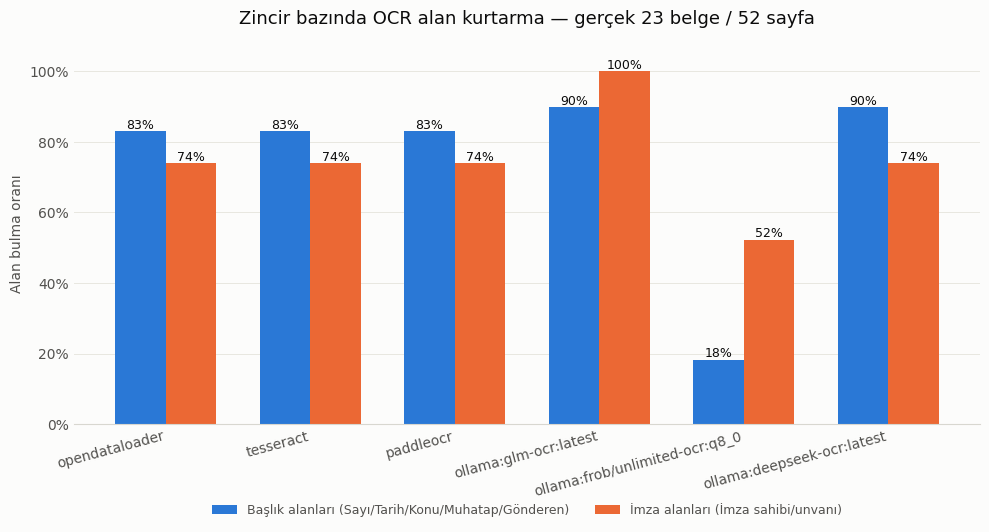


Kaydedildi: ocr_benchmark.svg, ocr_benchmark.png


In [13]:
COLOR_HEADER = "#2a78d6"
COLOR_SIGNATURE = "#eb6834"
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"

engines = list(results.keys())
header_pct, signature_pct = [], []
for name in engines:
    ch = results[name]["totals"]["chain"]
    header_pct.append(100 * ch["header"]["found"] / ch["header"]["expected"])
    signature_pct.append(100 * ch["signature"]["found"] / ch["signature"]["expected"])

x = np.arange(len(engines))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

bars1 = ax.bar(x - width / 2, header_pct, width, label="Başlık alanları (Sayı/Tarih/Konu/Muhatap/Gönderen)",
               color=COLOR_HEADER, edgecolor="none")
bars2 = ax.bar(x + width / 2, signature_pct, width, label="İmza alanları (İmza sahibi/unvanı)",
               color=COLOR_SIGNATURE, edgecolor="none")

for bars in (bars1, bars2):
    for b in bars:
        ax.annotate(f"{b.get_height():.0f}%", (b.get_x() + b.get_width() / 2, b.get_height()),
                    ha="center", va="bottom", fontsize=9, color=TEXT_PRIMARY)

ax.set_ylim(0, 108)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylabel("Alan bulma oranı", color=TEXT_SECONDARY)
ax.set_xticks(x)
ax.set_xticklabels(engines, rotation=15, ha="right", color=TEXT_PRIMARY)
ax.set_title("Zincir bazında OCR alan kurtarma — gerçek 23 belge / 52 sayfa",
             color=TEXT_PRIMARY, fontsize=13, pad=14)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#d8d7d0")
ax.tick_params(colors=TEXT_SECONDARY, length=0)
ax.grid(axis="y", color="#e8e7e0", linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False, fontsize=9, labelcolor=TEXT_SECONDARY)

plt.tight_layout()
plt.savefig("ocr_benchmark.svg", format="svg", bbox_inches="tight")
plt.savefig("ocr_benchmark.png", format="png", dpi=200, bbox_inches="tight")
plt.show()
print("\nKaydedildi: ocr_benchmark.svg, ocr_benchmark.png")

## 11. İndir

Ham JSON'u ve her iki grafiği (StudyApp baloncuk grafiği + KACHOW çift çubuk grafiği) indirin.

In [14]:
from google.colab import files
files.download(ev.DEFAULT_RESULTS_FILE)
files.download("ocr_bubble_benchmark.svg")
files.download("ocr_bubble_benchmark.png")
files.download("ocr_benchmark.svg")
files.download("ocr_benchmark.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>